In [10]:
import torch
import torchvision
import numpy as np
import sys
sys.path.append("..")
from d2l import torch as d2l_torch

In [11]:
batch_size = 256
train_iter, test_iter = d2l_torch.load_data_fashion_mnist(batch_size)

100.0%
100.0%
100.0%
100.0%


In [12]:
num_inputs = 784
num_outputs = 10

W = torch.tensor(np.random.normal(0, 0.01, (num_inputs, num_outputs)), dtype=torch.float)
b = torch.zeros(num_outputs, dtype=torch.float)

W.requires_grad_(True)
b.requires_grad_(True)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True)

In [13]:
X = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(X.sum(dim=0, keepdim=True))
print(X.sum(dim=1, keepdim=True))

tensor([[5, 7, 9]])
tensor([[ 6],
        [15]])


In [14]:
def softmax(X):
    X_exp = X.exp()
    partition = X_exp.sum(dim=1, keepdim=True)
    return X_exp / partition

In [15]:
X = torch.rand((2, 5))
X_prob = softmax(X)
print(X_prob, X_prob.sum(dim=1))

tensor([[0.1473, 0.1468, 0.2410, 0.2765, 0.1883],
        [0.2211, 0.2105, 0.1026, 0.2429, 0.2229]]) tensor([1., 1.])


In [16]:
def net(X):
    return softmax(torch.mm(X.view((-1, num_inputs)), W) + b)

In [17]:
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y = torch.LongTensor([0, 2])
y_hat.gather(1, y.view(-1, 1))

tensor([[0.1000],
        [0.5000]])

In [18]:
def cross_entropy(y_hat, y):
    return - torch.log(y_hat.gather(1, y.view(-1, 1)))

In [19]:
def accuracy(y_hat, y):
    return (y_hat.argmax(dim=1) == y).float().mean().item()

In [20]:
print(accuracy(y_hat, y))

0.5


In [21]:
def evaluate_accuracy(data_iter, net):
    acc_sum, n = 0, 0
    for X, y in data_iter:
        acc_sum += (net(X).argmax(dim=1) == y).float().sum().item()
        n += y.shape[0]
    return acc_sum / n

In [22]:
print(evaluate_accuracy(test_iter, net))

0.106


In [24]:
num_epochs, lr = 5, 0.1

def train_ch3(net, train_iter, test_iter, loss, num_epochs, batch_size, params=None, lr=None, optimizer=None):
    for epoch in range(num_epochs):
        train_l_sum, train_acc_sum, n = 0.0, 0.0, 0
        for X, y in train_iter:
            y_hat = net(X)
            l = loss(y_hat, y).sum()

            # 梯度清零
            if optimizer is not None:
                optimizer.zero_grad()
            elif params is not None and params[0].grad is not None:
                for param in params:
                    param.grad.data.zero_()

            l.backward()
            if optimizer is None:
                d2l_torch.sgd(params, lr, batch_size)
            else:
                optimizer.step()

            train_l_sum += l.item()
            train_acc_sum += (y_hat. argmax(dim=1) ==y).sum().item()
            n += y.shape[0]
        test_acc = evaluate_accuracy(test_iter, net)
        print('epoch %d, loss %.4f, train acc %.3f, test acc %.3f'
              % (epoch + 1, train_l_sum / n, train_acc_sum / n, test_acc))

train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, batch_size, [W, b], lr)

epoch 1, loss 0.7845, train acc 0.750, test acc 0.791
epoch 2, loss 0.5718, train acc 0.812, test acc 0.809
epoch 3, loss 0.5255, train acc 0.826, test acc 0.820
epoch 4, loss 0.5010, train acc 0.832, test acc 0.825
epoch 5, loss 0.4856, train acc 0.837, test acc 0.824


array([<Axes: title={'center': 'ankle boot\nankle boot'}>,
       <Axes: title={'center': 'pullover\npullover'}>,
       <Axes: title={'center': 'trouser\ntrouser'}>,
       <Axes: title={'center': 'trouser\ntrouser'}>,
       <Axes: title={'center': 'shirt\nshirt'}>,
       <Axes: title={'center': 'trouser\ntrouser'}>,
       <Axes: title={'center': 'coat\ncoat'}>,
       <Axes: title={'center': 'shirt\nshirt'}>,
       <Axes: title={'center': 'sandal\nsandal'}>], dtype=object)

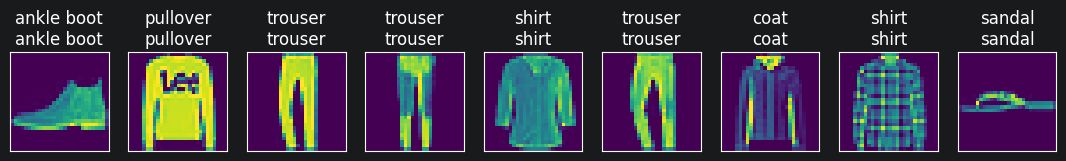

In [29]:
X, y = next(iter(test_iter))

true_labels = d2l_torch.get_fashion_mnist_labels(y.numpy())
pred_labels = d2l_torch.get_fashion_mnist_labels(net(X).argmax(dim=1).numpy())
titles = [true + '\n' + pred for true, pred in zip(true_labels, pred_labels)]

d2l_torch.show_images(X[0:9].reshape(9, 28, 28), 1, 9, titles = titles[0:9])